# Heath–Jarrow–Morton (HJM) Term Structure Modeling of U.S. Interest Rates
Author: Maximilian Yap, Cornell University

<h1>Table of Contents<span class="tocSkip"></span></h1>



## 0. Front Matter & Reproducibility

**Last Updated:**  
12-Jan-2025

**Repository:**  
<[GitHub repository link](https://github.com/mmy32/HJM-Libor-Model)>  
**Commit hash:** <short hash>

**Environment Specification:**  
- Python: 3.9+  
- Core libraries: `numpy`, `pandas`, `scipy`, `scikit-learn`, `plotly`, `statsmodels`  
- Optional: `dvc` for data versioning

**Execution Contract:**  
This notebook is designed to be executed **top-to-bottom** without manual intervention.  
All parameters controlling calibration windows, tenors, factor counts, and simulation horizons are defined explicitly in Section 4.

### What This Notebook Produces
- A clean, reproducible pipeline from raw yield data to:
  - factor-extracted curve dynamics,
  - arbitrage-consistent HJM drift and volatility terms,
  - simulated future yield curve scenarios.

**Expected Runtime:**  
~30 minutes on a standard laptop for calibration and diagnostics.


## 1. Executive Summary

### Objective
The goal of this project is to **model, calibrate, and simulate the evolution of the interest rate term structure** using a Heath–Jarrow–Morton (HJM) framework calibrated to historical U.S. Treasury yield data.



### Modeling Assumptions (High-Level)
- Interest rate dynamics are adequately captured by a **low-dimensional factor structure**.
- Historical yield movements are informative about future volatility (stationarity assumption).
- No-arbitrage conditions are enforced through the HJM drift restriction.


## 2. Introduction: Yield Curve Modeling and the HJM Framework

### 2.1 The Problem of Yield Curve Fitting
Interest rates are observed at a discrete set of maturities, yet many financial applications, such as risk management, scenario analysis, and pricing, require a **continuous, arbitrage-consistent representation of the entire yield curve** as it evoloves over time. Empirically, yield curves must satisfy several competing requirements: they should fit observed market data closely, evolve smoothly across maturities, and generate realistic dynamics over time. Naïve fitting approaches often fail one or more of these criteria, leading to unstable extrapolations, implausible curve shapes, or violations of no-arbitrage conditions.


The Heath–Jarrow–Morton (HJM) framework provides a theoretically rigorous solution by modeling the **entire forward rate curve as a stochastic process**. Rather than specifying dynamics for a single short rate, HJM directly characterizes the evolution of forward rates across maturities. Crucially, once the volatility structure of the forward curve is specified, the drift is uniquely determined by a no-arbitrage condition. This makes HJM a natural framework for generating arbitrage-free yield curve dynamics and coherent multi-maturity scenarios.

### 2.2 Limitations of a Naïve HJM Implementation
Despite its theoretical appeal, a basic HJM implementation faces several practical challenges:
- The forward curve is infinite-dimensional, making unrestricted volatility specification infeasible.
- Arbitrary volatility choices can lead to unstable or economically implausible dynamics.
- Estimating a high-dimensional volatility structure directly from data is noisy and prone to overfitting.
- Without dimensionality reduction, simulations become computationally expensive and difficult to interpret.

These issues limit the usefulness of HJM unless additional structure is imposed.

### 2.3 PCA as a Practical Resolution

Empirically, yield curve movements are highly correlated and can be well-approximated by a **small number of common factors**. Principal Component Analysis (PCA) exploits this structure by identifying the dominant modes of variation—commonly interpreted as level, slope, and curvature effects. By projecting historical yield (or forward rate) changes onto a low-dimensional factor space, PCA provides:
- a parsimonious and data-driven volatility specification,
- noise reduction and improved stability,
- interpretable economic dynamics.

Embedding these PCA-derived factors into the HJM framework yields a **low-dimensional, arbitrage-consistent model** that remains faithful to observed yield curve behavior.

### 2.5 Process Overview and Intended Usefulness
This notebook implements the following pipeline:
1. ingest and clean historical yield curve data,
2. extract dominant factors via PCA,
3. map factor volatilities into an HJM-consistent volatility structure,
4. compute the implied no-arbitrage drift,
5. simulate future yield curve scenarios and validate their properties.

The ultimate objective is to produce a **transparent, reproducible, and interpretable yield curve model** that balances theoretical soundness with empirical realism. While not intended as a production pricing system, the framework is designed to be a useful foundation for scenario generation, stress testing, and further extensions in quantitative fixed-income research.



## 3. Data & Provenance

The data source of this project is a panel of U.S. Treasury constant maturity yields obtained directly from the Federal Reserve Economic Data (FRED) database. 

The download script under `src/data_processing/data_download.py` queries a set of standard Treasury yield series identified by their FRED symbols (e.g., DGS1MO, DGS2, DGS10), each corresponding to a fixed maturity. These series are mapped to numeric tenors measured in years, allowing the yield curve to be represented on a common and interpretable maturity axis. Data are retrieved from a user-specified start date through the present, merged into a single time-indexed matrix, and aligned by date. The resulting structure is a rectangular panel with observation dates along the rows and maturities along the columns.

Raw yields from FRED are reported in percentage terms. The script converts these values into decimals to ensure internal consistency with continuous-time modeling conventions. Missing observations are forward-filled to maintain temporal continuity, after which any remaining incomplete rows are removed. This produces a dataset without gaps, suitable for principal component analysis and subsequent estimation of HJM volatility structures. While forward-filling imposes a strong assumption—namely that unobserved quotes remain unchanged—it avoids introducing artificial noise through interpolation and preserves the joint cross-sectional structure of the curve. The consequences of this choice are revisited later through diagnostic checks on factor stability and residual behavior.

Once constructed, the dataset is written to `data/treasury_yields.csv`. This file serves as the canonical input for the remainder of the project, including visualization, factor extraction, and simulation. All subsequent code assumes that this file exists and conforms to the schema produced by the download script.

The cell below executes the same logic as the standalone script, generating the yield matrix within the notebook environment and returning it as a pandas DataFrame. Successful execution confirms that the data required for the HJM calibration pipeline have been built correctly and are available for further analysis.



In [1]:
import sys
from pathlib import Path

# If your notebook is in ./notebooks, this points to repo root
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists() is False:
    PROJECT_ROOT = Path.cwd().parent  # adjust if needed

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:

from src.data_processing.data_download import get_treasury_matrix

df = get_treasury_matrix(start_date="2018-01-01")
df.head()

--- Starting Data Ingestion ---
Targeting 11 tenors from 2018-01-01 to 2026-01-14
[*] Fetching DGS1MO (0.0833 year tenor)... Done.
[*] Fetching DGS3MO (0.25 year tenor)... Done.
[*] Fetching DGS6MO (0.5 year tenor)... Done.
[*] Fetching DGS1 (1.0 year tenor)... Done.
[*] Fetching DGS2 (2.0 year tenor)... Done.
[*] Fetching DGS3 (3.0 year tenor)... Done.
[*] Fetching DGS5 (5.0 year tenor)... Done.
[*] Fetching DGS7 (7.0 year tenor)... Done.
[*] Fetching DGS10 (10.0 year tenor)... Done.
[*] Fetching DGS20 (20.0 year tenor)... Done.
[*] Fetching DGS30 (30.0 year tenor)... Done.
--- Processing Data ---
Cleaned data: Kept 2006 of 2096 rows after removing NaNs.
[SUCCESS] Data saved to data/treasury_yields.csv


,0.0833,0.2500,0.5000,1.0000,2.0000,3.0000,5.0000,7.0000,10.0000,20.0000,30.0000
DATE,,,,,,,,,,,
2018-01-02,0.0129,0.0144,0.0161,0.0183,0.0192,0.0201,0.0225,0.0238,0.0246,0.0264,0.0281
2018-01-03,0.0129,0.0141,0.0159,0.0181,0.0194,0.0202,0.0225,0.0237,0.0244,0.0262,0.0278
2018-01-04,0.0128,0.0141,0.0160,0.0182,0.0196,0.0205,0.0227,0.0238,0.0246,0.0262,0.0279
2018-01-05,0.0127,0.0139,0.0158,0.0180,0.0196,0.0206,0.0229,0.0240,0.0247,0.0264,0.0281
2018-01-08,0.0130,0.0145,0.0160,0.0179,0.0196,0.0207,0.0229,0.0241,0.0249,0.0265,0.0281


After execution, the DataFrame index consists of observation dates, the columns correspond to maturities expressed as floating-point numbers in years, and the entries contain Treasury yields in decimal form. This representation provides a direct and transparent link between the raw market data and the stochastic term-structure model developed in the subsequent sections.


## 4. Nelson–Siegel Curve Representation

The yield data obtained from FRED are observed at a finite and irregular set of maturities. Using these discrete observations directly in a continuous-time term structure model introduces both conceptual and numerical difficulties. Subsequent steps in this project—factor extraction, volatility estimation, and HJM-based simulation—require a smooth representation of the yield curve defined on a dense maturity grid. The Nelson–Siegel specification is introduced here to impose a parsimonious functional structure on the cross section of yields while remaining tightly anchored to observed market data.

The Nelson–Siegel model expresses the zero-coupon yield at maturity $ \tau $ as a linear combination of three maturity-dependent loading functions:
$$
y(\tau)
=
\beta_0
+
\beta_1 \frac{1 - e^{-\lambda \tau}}{\lambda \tau}
+
\beta_2 \left(
\frac{1 - e^{-\lambda \tau}}{\lambda \tau}
-
e^{-\lambda \tau}
\right).
$$

The parameter $ \beta_0 $ determines the long-maturity level of the yield curve, since its loading converges to one as $ \tau \to \infty $. The parameter $ \beta_1 $ primarily influences short maturities through a monotonically decaying loading, shaping the slope of the curve. The parameter $ \beta_2 $ loads on a hump-shaped function, allowing the curve to exhibit curvature at intermediate maturities. The decay parameter $ \lambda $ governs both the location of this hump and the rate at which short- and medium-term effects decay with maturity.

In this notebook, the Nelson–Siegel model is fitted independently for each observation date. For a given day, the parameter vector
$$
(\beta_0, \beta_1, \beta_2, \lambda)
$$
is chosen to minimize the squared deviation between observed Treasury yields and the Nelson–Siegel curve evaluated at the corresponding maturities. The estimation relies on a global, derivative-free optimization routine to reduce sensitivity to local minima and to accommodate the nonlinear dependence on the decay parameter $ \lambda $. Numerical issues at zero maturity are avoided by enforcing a small positive lower bound in the implementation.

The output of this procedure is a time series of Nelson–Siegel parameters, with one parameter vector per trading day. These estimates are stored in multiple formats to support downstream analysis and reuse outside the notebook environment. Alongside the parameter estimates, a dense maturity grid is constructed, allowing each fitted curve to be evaluated smoothly from near-zero maturity out to thirty years.

This step plays a dual role in the overall modeling pipeline. It provides a smoothed and economically interpretable reconstruction of the observed yield curves, filtering out high-frequency cross-sectional noise while preserving dominant shape features. At the same time, it yields a low-dimensional state representation of curve dynamics. In later sections, these fitted curves and parameter paths form the basis for principal component analysis and for linking empirical yield movements to the volatility structure required by the HJM model.



In [3]:

from src.curves.nelson_siegel_curves import main

# Run the pipeline
# Note: Ensure the data_path points correctly from the notebook's perspective
params_df, params_dict, fig = main(
    data_path="../data/treasury_yields.csv", 
    build_viz=True,
    viz_sample_every=15 # Adjust this to make the slider faster or more detailed
)

# Explicitly display the figure if it doesn't show up automatically
if fig:
    fig.show()

--- Calibrating 2086 frames (all days) ---


Processing All Days:   0%|          | 0/2086 [00:00<?, ?it/s]


✓ Saved CSV to: data/ns_parameters/ns_parameters.csv
✓ Saved Pickle to: data/ns_parameters/ns_parameters.pkl
✓ Saved NumPy arrays to: data/ns_parameters/ns_parameters_array.npy

--- Building visualization with 140 frames ---


Building Viz:   0%|          | 0/140 [00:00<?, ?it/s]


PARAMETER SUMMARY STATISTICS
          b0_level     b1_slope  b2_curvature       lambda
count  2086.000000  2086.000000   2086.000000  2086.000000
mean      0.033938    -0.007902     -0.011880     0.740241
std       0.011065     0.012580      0.021640     0.601793
min       0.000060    -0.035432     -0.048375     0.012642
25%       0.024746    -0.018090     -0.026748     0.339875
50%       0.031751    -0.009274     -0.018830     0.498562
75%       0.044721     0.001360      0.000013     0.966849
max       0.060211     0.042341      0.082356     2.000000

Data saved and ready for PCA analysis!


## 5. Principal Component Analysis of Nelson–Siegel Parameters

The **Nelson–Siegel calibration** yields, for each observation date $t$, a four-dimensional parameter vector capturing the cross-sectional shape of the yield curve. Let
$$\theta_t = (\beta_{0,t}, \beta_{1,t}, \beta_{2,t}, \lambda_t)^\top$$
denote the parameter vector on date $t$, and collect these vectors over the sample into the matrix
$$\Theta =
\begin{pmatrix}
\theta_1^\top \\
\theta_2^\top \\
\vdots \\
\theta_T^\top
\end{pmatrix}
\in \mathbb{R}^{T \times 4}.$$
Although this representation is already low-dimensional relative to the original yield curve, the individual parameters exhibit strong co-movement over time. Treating them as independent state variables would therefore be redundant and would obscure the dominant directions along which yield curve shapes evolve.

Before applying **Principal Component Analysis (PCA)**, each column of $\Theta$ is standardized to remove differences in scale across parameters. Denoting by $\mu_j$ and $\sigma_j$ the sample mean and standard deviation of parameter $j$, the standardized matrix is defined elementwise as
$$\tilde{\Theta}_{t,j}
=
\frac{\Theta_{t,j} - \mu_j}{\sigma_j}.$$
This step ensures that the resulting components reflect patterns of joint variation rather than arbitrary differences in units or magnitude between, for example, level and decay parameters.

PCA is then applied to the standardized parameter matrix $\tilde{\Theta}$. Formally, PCA proceeds by constructing the **sample covariance matrix**
$$\Sigma
=
\frac{1}{T-1}
\tilde{\Theta}^\top \tilde{\Theta},$$
and solving the associated **eigenvalue problem**
$$\Sigma v_k = \lambda_k v_k,$$
where $\lambda_k$ is the $k$-th largest eigenvalue and $v_k$ is the corresponding eigenvector. The eigenvectors define orthogonal directions in parameter space, ordered by the amount of variance explained, while the eigenvalues quantify the contribution of each direction to total variation.

The **principal component scores** are obtained by projecting the standardized parameters onto these eigenvectors. For each date $t$, the score of the $k$-th principal component is given by
$$z_{t,k} = \tilde{\Theta}_t^\top v_k,$$
or, in matrix form,
$$Z = \tilde{\Theta} V,$$
where $V = (v_1, v_2, \dots, v_4)$. These scores form time series that represent the evolution of the yield curve's primary factors.

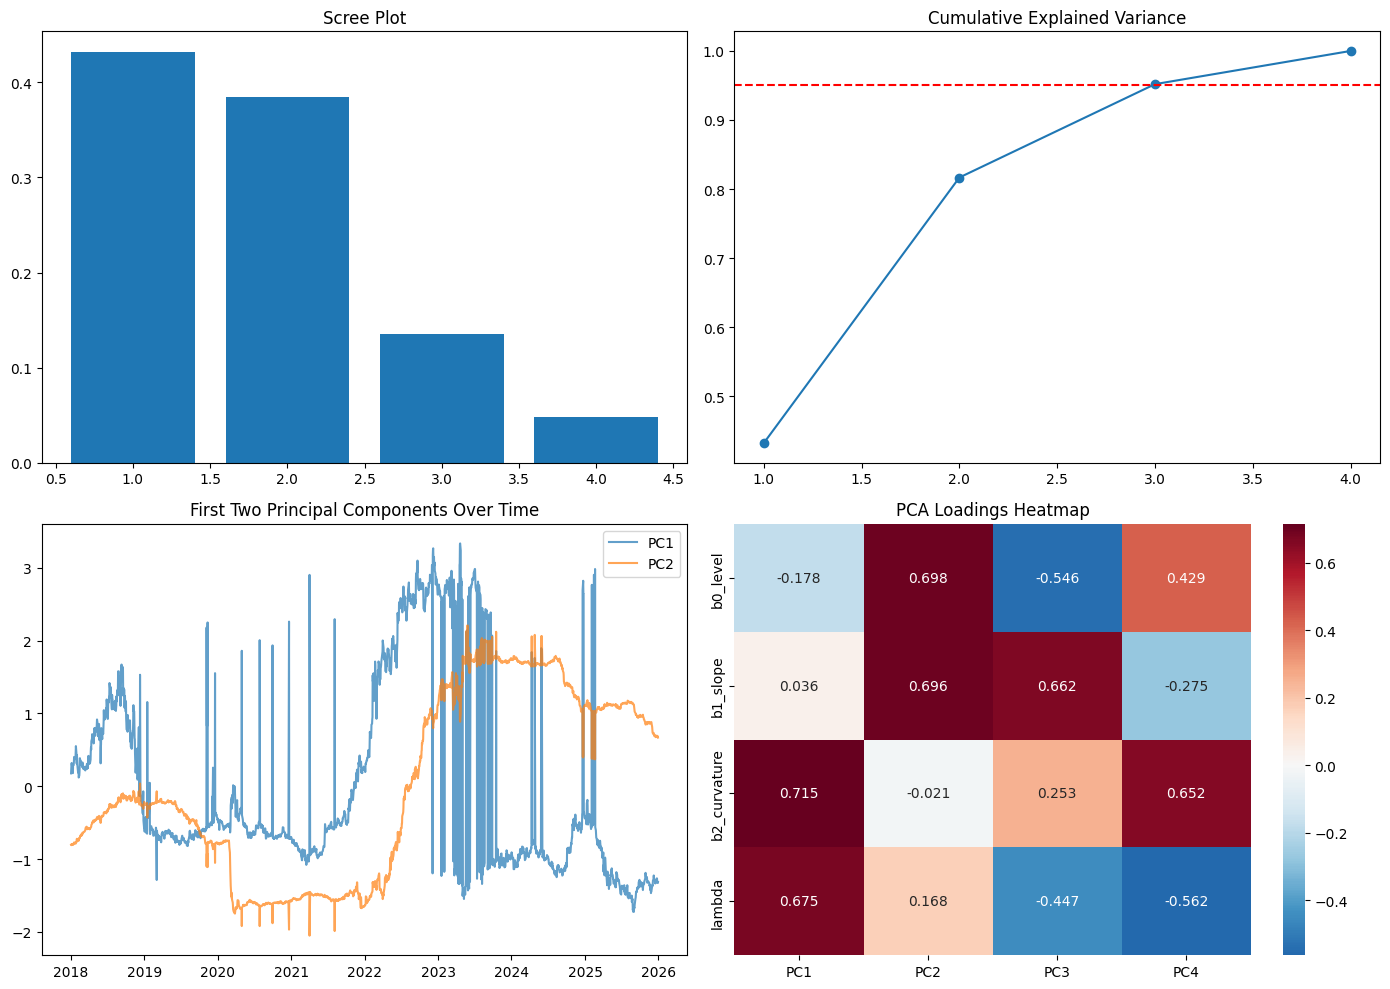

Variance explained by first 3 components: 95.19%


In [4]:

from src.calibration.pca import run_pca_analysis

# Run the PCA
# We pass the relative path from the notebook's perspective
pca_df, loadings, pca_model, fig = run_pca_analysis(
    input_path="../data/ns_parameters/ns_parameters.csv",
    output_dir="../data/ns_parameters/",
    show_plot=True
)

# You can now access the explained variance directly in the notebook:
print(f"Variance explained by first 3 components: {sum(pca_model.explained_variance_ratio_[:3])*100:.2f}%")

## 6. Estimating Principal Component (PC) Processes

At this point, we have compressed the time-varying Nelson–Siegel parameter vector
$$\theta_t = (\beta_{0,t}, \beta_{1,t}, \beta_{2,t}, \lambda_t)^\top$$
into a small set of orthogonal principal components. The PCA step produces:

- **Loadings** (eigenvectors): how each PC maps back to combinations of NS parameters and therefore yield-curve shape changes.
- **PC scores** (time series): how strongly each PC is active on each date.

To simulate future yield curves or build a state-space term-structure model, we need one missing piece:

> **A stochastic law of motion for the PC scores through time.**

This section treats each PC score series as a latent factor and fits a parsimonious continuous-time process to it.

---

### Why model PC scores as Ornstein–Uhlenbeck (OU) processes?

We model each PC score $X_t$ with an OU process:
$$dX_t = \kappa(\theta - X_t)\,dt + \sigma\,dW_t$$
where:
- $\kappa > 0$ is the mean-reversion speed
- $\theta$ is the long-run mean
- $\sigma$ is the diffusion volatility
- $W_t$ is Brownian motion

This choice reflects several empirical regularities in yield-curve factor dynamics:

1. **Rates and curve factors are empirically mean-reverting**  
   Yield-curve level, slope, and curvature drift back toward normal regimes after shocks rather than following a pure random walk.

2. **OU is the continuous-time analogue of AR(1)**  
   Discretely sampled OU has the conditional mean
   $$\mathbb{E}[X_{t+\Delta} \mid X_t] = \theta + (X_t-\theta)e^{-\kappa\Delta}$$
   which matches exactly the structure of an AR(1) with persistence $e^{-\kappa\Delta}$.  
   PC scores exhibit this kind of decaying autocorrelation.

3. **Stationary distribution is well-defined**  
   Under OU, $X_t$ has a stationary distribution:
   $$X_\infty \sim \mathcal{N}\!\left(\theta,\ \frac{\sigma^2}{2\kappa}\right)$$
   Factor realizations fluctuate around a stable center with a stable long-run variance.

4. **Interpretability and calibration friendliness**  
   $\kappa$ maps cleanly to a half-life of shocks:
   $$t_{1/2}=\frac{\ln 2}{\kappa}$$
   so we can describe factor persistence in intuitive units (e.g., "PC1 shocks halve in ~40 trading days").

Real rate dynamics can exhibit regime shifts, time-varying volatility, and correlated factors. OU is not "true" in a strict sense. But it provides a strong baseline: simple, interpretable, and fits PC autocorrelation structure surprisingly well.

---

### What `estimate_pc_processes.py` does

This script implements the following workflow:

1. **Load PC score time series**  
   We read `principal_components.csv`, where each column $PC_k$ is a daily time series of scores.

2. **Estimate OU parameters via Maximum Likelihood (MLE)**  
   For discretely observed OU, the exact transition density is Gaussian:
   $$X_{t+\Delta}\mid X_t \sim \mathcal{N}\!\left(
   \theta + (X_t-\theta)e^{-\kappa\Delta},\ 
   \frac{\sigma^2}{2\kappa}(1-e^{-2\kappa\Delta})
   \right)$$
   The code defines the negative log-likelihood from this transition distribution and uses constrained optimization to estimate $(\kappa,\theta,\sigma)$.

3. **Repeat for each principal component**  
   Each PC gets its own parameter triplet. This yields a factor-by-factor view of:
   - how persistent the factor is ($\kappa$, half-life),
   - what level it mean-reverts to ($\theta$),
   - how volatile its innovations are ($\sigma$).

4. **Run diagnostics to validate the OU assumption**
   For each PC, the notebook produces:
   - a time series plot with the fitted long-run mean $\theta$,
   - a histogram overlaid with the OU stationary normal density,
   - an empirical ACF compared to the OU theoretical ACF:
     $$\rho(\tau)=e^{-\kappa\tau}$$
   These plots serve as the main sanity check that OU reasonably approximates the data.

5. **Persist results for later simulation**
   The fitted parameters are saved to:
   - `data/ns_parameters/ou_parameters.json`
   - `data/ns_parameters/ou_parameters.csv`

   These will be used downstream to simulate factor paths and reconstruct yield curves through the PCA + Nelson–Siegel mapping.

---

### How to interpret the outputs

For each $PC_k$:

- **Large $\kappa$** → fast mean reversion → low persistence  
- **Small $\kappa$** → slow mean reversion → high persistence  
- **Half-life** (in trading days) gives a direct persistence measure:
  - short half-life: shocks fade quickly
  - long half-life: shocks linger
- **Stationary standard deviation**
  $$\sigma_\text{stat}=\frac{\sigma}{\sqrt{2\kappa}}$$
  quantifies long-run variability of the factor (how wide its typical range is over time).

---

### What this enables next

Once we have OU parameters for the leading PCs, we can:

1. Simulate future factor paths $PC_t$
2. Map factors back to NS parameters using PCA loadings
3. Construct future yield curves from Nelson–Siegel
4. Embed this into an HJM-style simulation pipeline where the state evolves in factor space (optional).

PCA gave us a low-dimensional state; OU estimation gives us the dynamics of that state.

Loaded PC scores shape: (2086, 4)

First few rows:
                 PC1       PC2       PC3       PC4
2018-01-02  0.176894 -0.802301  0.270565  0.507212
2018-01-03  0.238866 -0.808066  0.268424  0.451839
2018-01-04  0.297561 -0.802740  0.244673  0.411420
2018-01-05  0.319316 -0.808198  0.190772  0.393654
2018-01-08  0.246298 -0.797613  0.232316  0.463584

ESTIMATING OU PARAMETERS FOR EACH PRINCIPAL COMPONENT

PC1:
  κ (mean reversion speed): 44.5920
  θ (long-run mean):        -0.0038
  σ (volatility):           12.4379
  Half-life:                3.9 days
  Log-likelihood:           -2271.87

PC2:
  κ (mean reversion speed): 0.5157
  θ (long-run mean):        0.3447
  σ (volatility):           1.2504
  Half-life:                338.7 days
  Log-likelihood:           2343.21

PC3:
  κ (mean reversion speed): 50.0000
  θ (long-run mean):        -0.0035
  σ (volatility):           8.2949
  Half-life:                3.5 days
  Log-likelihood:           -1405.82

PC4:
  κ (mean reversion s

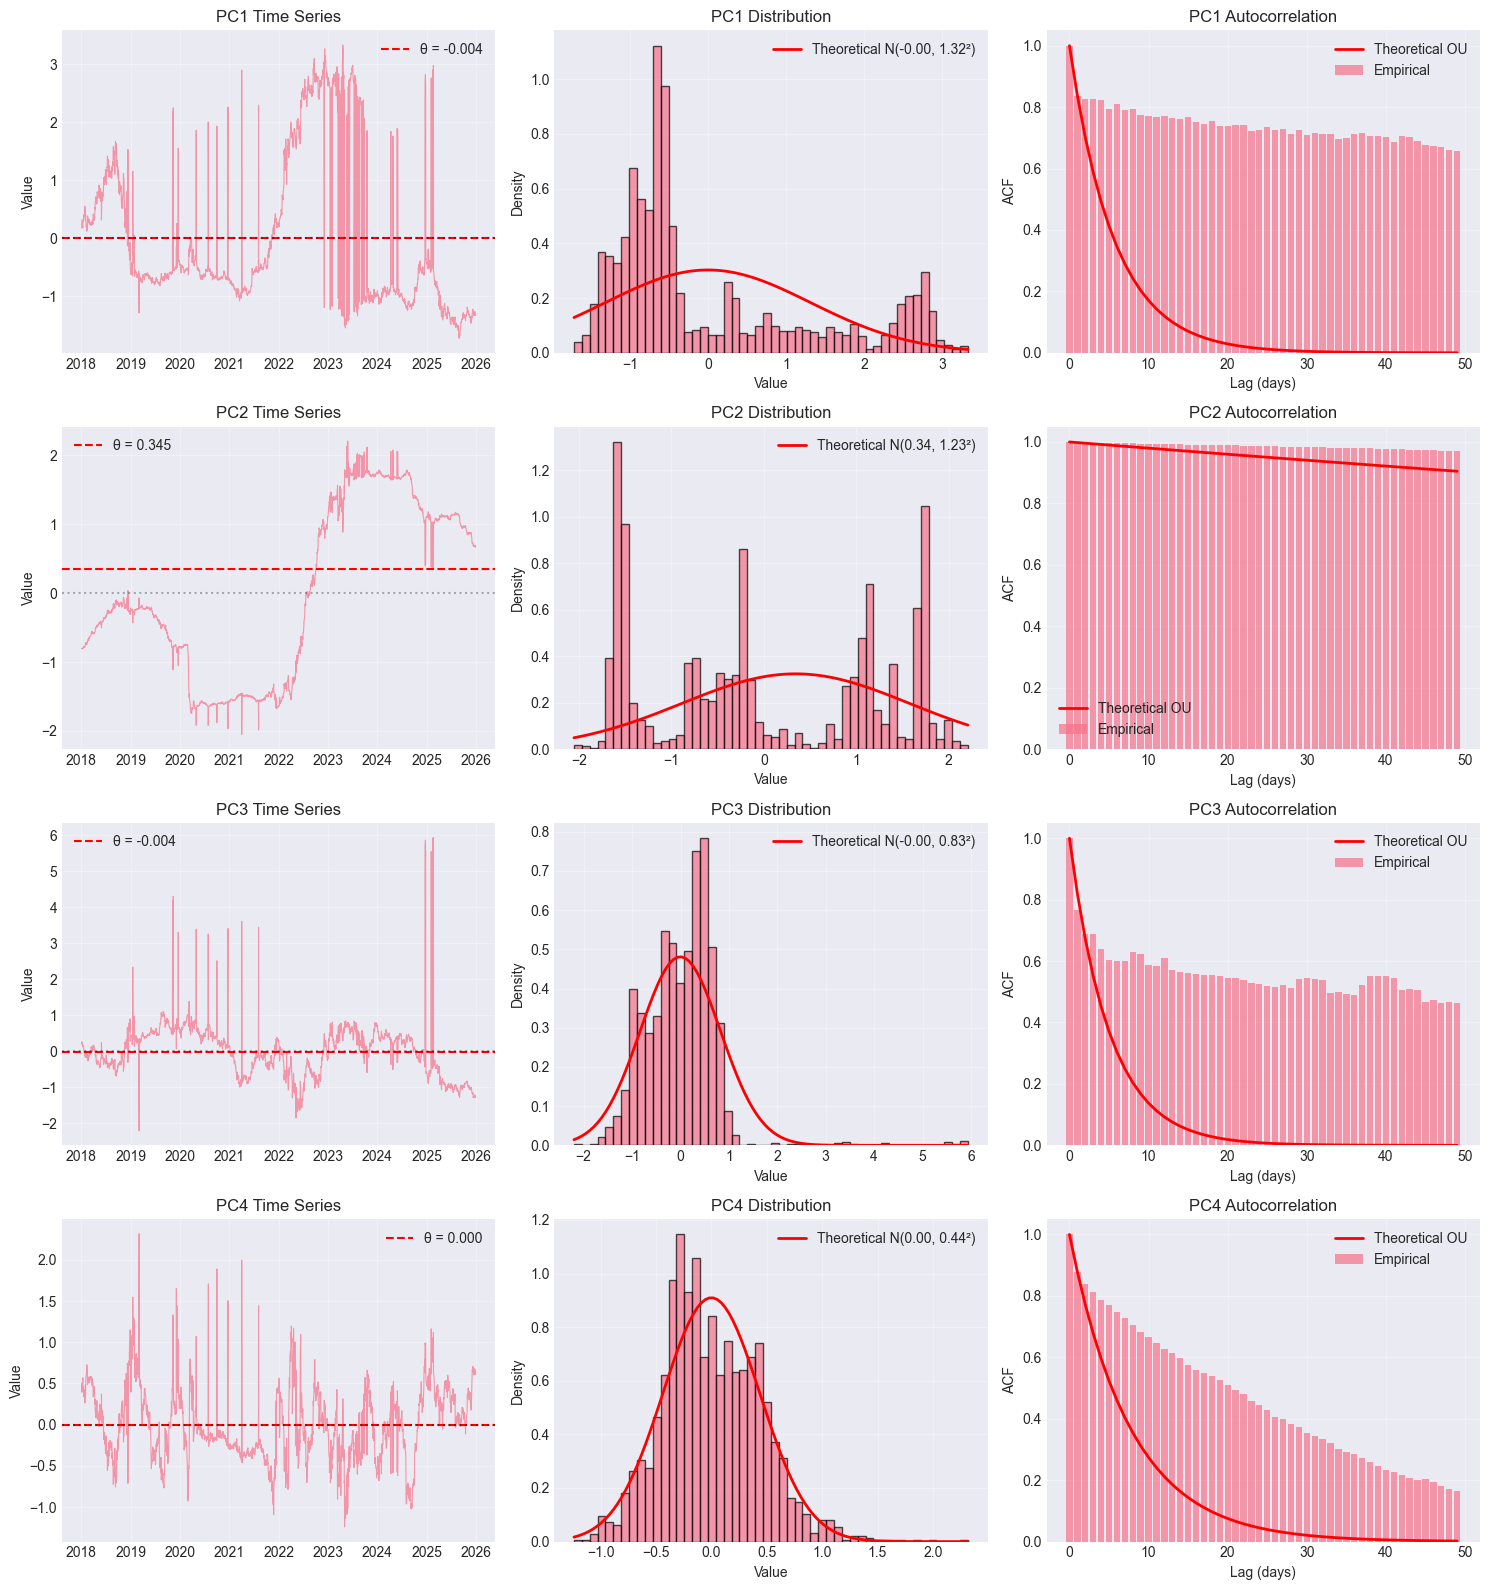


✓ OU parameters estimated and saved!
  - Parameters (JSON): data/ns_parameters/ou_parameters.json
  - Parameters (CSV):  data/ns_parameters/ou_parameters.csv
  - Diagnostics plot:  data/ns_parameters/ou_diagnostics.png

SUMMARY:
----------------------------------------------------------------------
PC     κ (speed)    Half-life       σ (vol)      Stationary σ   
----------------------------------------------------------------------
PC1       44.5920           3.9 d     12.4379         1.3171
PC2        0.5157         338.7 d      1.2504         1.2312
PC3       50.0000           3.5 d      8.2949         0.8295
PC4       32.6267           5.4 d      3.5416         0.4384
----------------------------------------------------------------------

Interpretation:
  - Higher κ → faster mean reversion → less persistent
  - Lower half-life → shocks dissipate quickly
  - Stationary σ → long-run standard deviation of PC


In [6]:
# run estimate_pc_process.py here
%run ../src/calibration/estimate_pc_process.py

## 7. Computing Nelson–Siegel Sensitivities

### The Bridge from Parameters to Forward Rates

We model the evolution of the Nelson–Siegel parameter vector $\theta = (\beta_0, \beta_1, \beta_2, \lambda)^\top$ through PCA-driven dynamics. But our ultimate target is the forward rate curve $f(t,T)$ at each maturity $T$. We need a precise mapping between parameter movements and forward rate changes.

This section computes that mapping through **analytical sensitivities**—the partial derivatives of the forward rate with respect to each NS parameter.

---

### NS Sensitivities: Partial Derivatives

For each maturity $T$, the Nelson–Siegel forward rate is:
$$f(T) = \beta_0 + \beta_1 \cdot e^{-T/\lambda} + \beta_2 \cdot \frac{T}{\lambda} \cdot e^{-T/\lambda}$$

The sensitivities capture how $f(T)$ responds to infinitesimal changes in each parameter:

$$\frac{\partial f(T)}{\partial \beta_0} = 1$$
*All maturities are equally affected by the level parameter.*

$$\frac{\partial f(T)}{\partial \beta_1} = e^{-T/\lambda}$$
*Short maturities are more sensitive to the slope parameter; sensitivity decays exponentially.*

$$\frac{\partial f(T)}{\partial \beta_2} = \frac{T}{\lambda} \cdot e^{-T/\lambda}$$
*Medium maturities exhibit peak sensitivity to the curvature parameter; this creates the characteristic hump.*

$$\frac{\partial f(T)}{\partial \lambda} = \frac{T}{\lambda^2} \cdot e^{-T/\lambda} \cdot \left[\beta_1 - \beta_2 \left(\frac{T}{\lambda} - 1\right)\right]$$
*Changes in $\lambda$ shift the location and intensity of the curvature hump.*

---

### Why These Sensitivities Matter

**Translating parameter changes to curve changes:**

For a small perturbation in parameters $\Delta\theta = (\Delta\beta_0, \Delta\beta_1, \Delta\beta_2, \Delta\lambda)^\top$, the change in the forward rate at maturity $T$ is:

$$\Delta f(T) = \frac{\partial f}{\partial \beta_0} \Delta\beta_0 + \frac{\partial f}{\partial \beta_1} \Delta\beta_1 + \frac{\partial f}{\partial \beta_2} \Delta\beta_2 + \frac{\partial f}{\partial \lambda} \Delta\lambda$$

This is the chain rule linking parameter dynamics to curve dynamics. Without these sensitivities, we cannot translate the stochastic evolution of $\theta_t$ into the stochastic evolution of the forward rate surface.

---

### Connecting to Principal Components

Recall that we decomposed NS parameters into orthogonal factors:
$$\theta_t = \bar{\theta} + W \cdot \alpha_t$$
where $W$ is the loading matrix and $\alpha_t$ are the PC scores.

The differential of each parameter is:
$$d\theta_i = \sum_j W_{ij} \, d\alpha_j$$

Substituting into the forward rate differential:
$$df(t,T) = \sum_i \frac{\partial f}{\partial \theta_i} \, d\theta_i = \sum_i \frac{\partial f}{\partial \theta_i} \sum_j W_{ij} \, d\alpha_j$$

Rearranging:
$$df(t,T) = \sum_j \underbrace{\left[\sum_i \frac{\partial f}{\partial \theta_i} \cdot W_{ij}\right]}_{\text{sensitivity to } PC_j} d\alpha_j$$

This composite sensitivity tells us: **a one-unit movement in $PC_j$ produces what change in the forward rate at maturity $T$?**

---

### Forward Rate Volatility Structure

If each PC follows an OU process with diffusion $\sigma_{\alpha_j}$, the instantaneous volatility of the forward rate at maturity $T$ is:

$$\sigma_{\text{forward}}(T) = \sqrt{\sum_j \left[\sum_i \frac{\partial f}{\partial \theta_i} \cdot W_{ij}\right]^2 \sigma_{\alpha_j}^2}$$

This decomposes the forward rate's volatility across maturities into contributions from each principal component. We can now answer:
- Which PC drives most of the volatility at the short end? (Typically PC1 or PC2)
- Which PC drives the belly of the curve? (Often PC3, the curvature factor)
- How does volatility vary across the term structure?

These sensitivities are the foundation for HJM drift restrictions, Monte Carlo simulation of yield curves, and risk decomposition in fixed-income portfolios.

---

### What `compute_ns_sensitivities.py` Does

This script:

1. **Loads mean NS parameters** from the calibration step
2. **Computes analytical partial derivatives** $\frac{\partial f}{\partial \theta_i}$ across a grid of maturities
3. **Loads PCA loadings** $W$ and computes composite sensitivities $\frac{\partial f}{\partial PC_j}$
4. **Visualizes** how each parameter and each PC affects different parts of the curve
5. **Saves results** for downstream simulation

The outputs quantify precisely how factor movements propagate through the term structure—this is the machinery that converts low-dimensional stochastic dynamics into rich forward rate surface evolution.

COMPUTING NELSON-SIEGEL SENSITIVITIES

Loaded columns: ['b0_level', 'b1_slope', 'b2_curvature', 'lambda']

Mean NS Parameters:
  β₀ (level):     0.0339
  β₁ (slope):     -0.0079
  β₂ (curvature): -0.0119
  λ (decay):      0.7402

Computing sensitivities for 19 maturities:
  Range: 0.25Y to 30.0Y

Sample sensitivities (5Y maturity):
  ∂f/∂β₀ = 1.0000
  ∂f/∂β₁ = 0.0012
  ∂f/∂β₂ = 0.0079
  ∂f/∂λ  = 0.0006


/Users/MaximilianYap/HJM Libor Model/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning:

Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.

/Users/MaximilianYap/HJM Libor Model/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning:

Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.

/Users/MaximilianYap/HJM Libor Model/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.

/Users/MaximilianYap/HJM Libor Model/src/calibration/compute_ns_sensitivities.py:181: UserWarning:

Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.

/Users/MaximilianYap/HJM Libor Model/src/calibration/compute_ns_sensitivities.py:181: UserWarning:

Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.

/Users/MaximilianYap/HJM Libor Model/src/calibration/compute_ns_sensitivities.py:181: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.

/Users/MaximilianYap/HJ

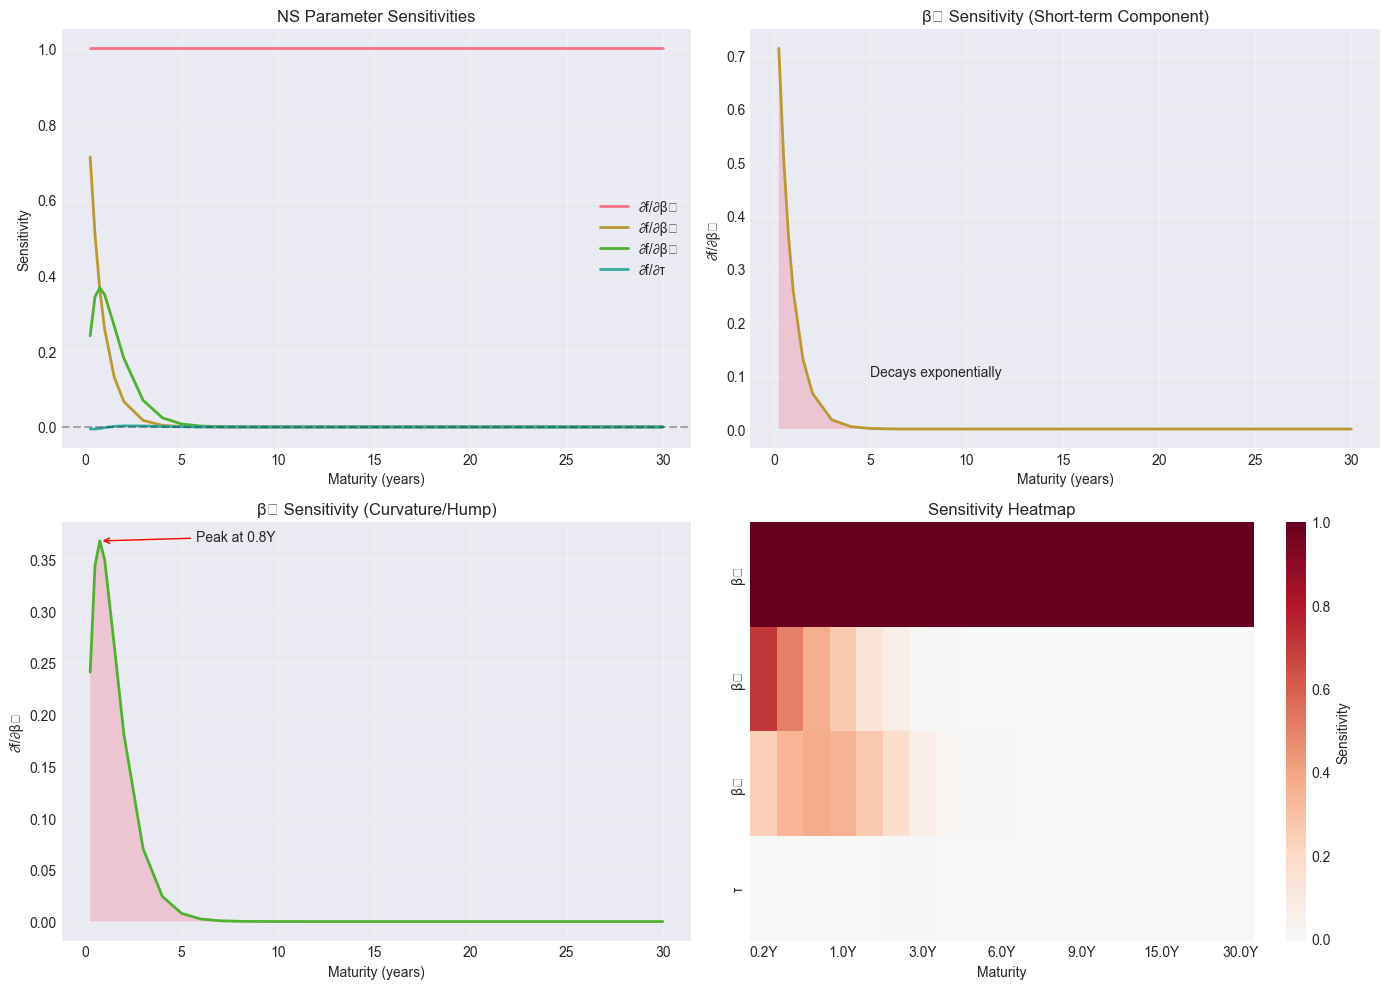


MAPPING PC MOVEMENTS TO FORWARD RATE CHANGES

PCA Loadings:
                   PC1       PC2       PC3       PC4
b0_level     -0.177937  0.697551 -0.545742  0.428866
b1_slope      0.036454  0.696234  0.662194 -0.274643
b2_curvature  0.714952 -0.020632  0.252594  0.651624
lambda        0.675169  0.168093 -0.447058 -0.562166

Loadings index (row names): ['b0_level', 'b1_slope', 'b2_curvature', 'lambda']

PC Sensitivities (how 1-unit PC move affects forward rates):
               PC1       PC2       PC3       PC4
maturity                                        
0.25      0.016857  1.188403 -0.010187  0.392821
0.50      0.082697  1.043871 -0.119464  0.516163
0.75      0.095692  0.942090 -0.210688  0.571016
1.00      0.080468  0.870363 -0.285062  0.586722
1.50      0.018878  0.784074 -0.391680  0.565845
2.00     -0.043874  0.741024 -0.456886  0.526852
3.00     -0.125139  0.708649 -0.517656  0.468462
4.00     -0.159403  0.700428 -0.537272  0.442656
5.00     -0.171832  0.698309 -0.543269  0.

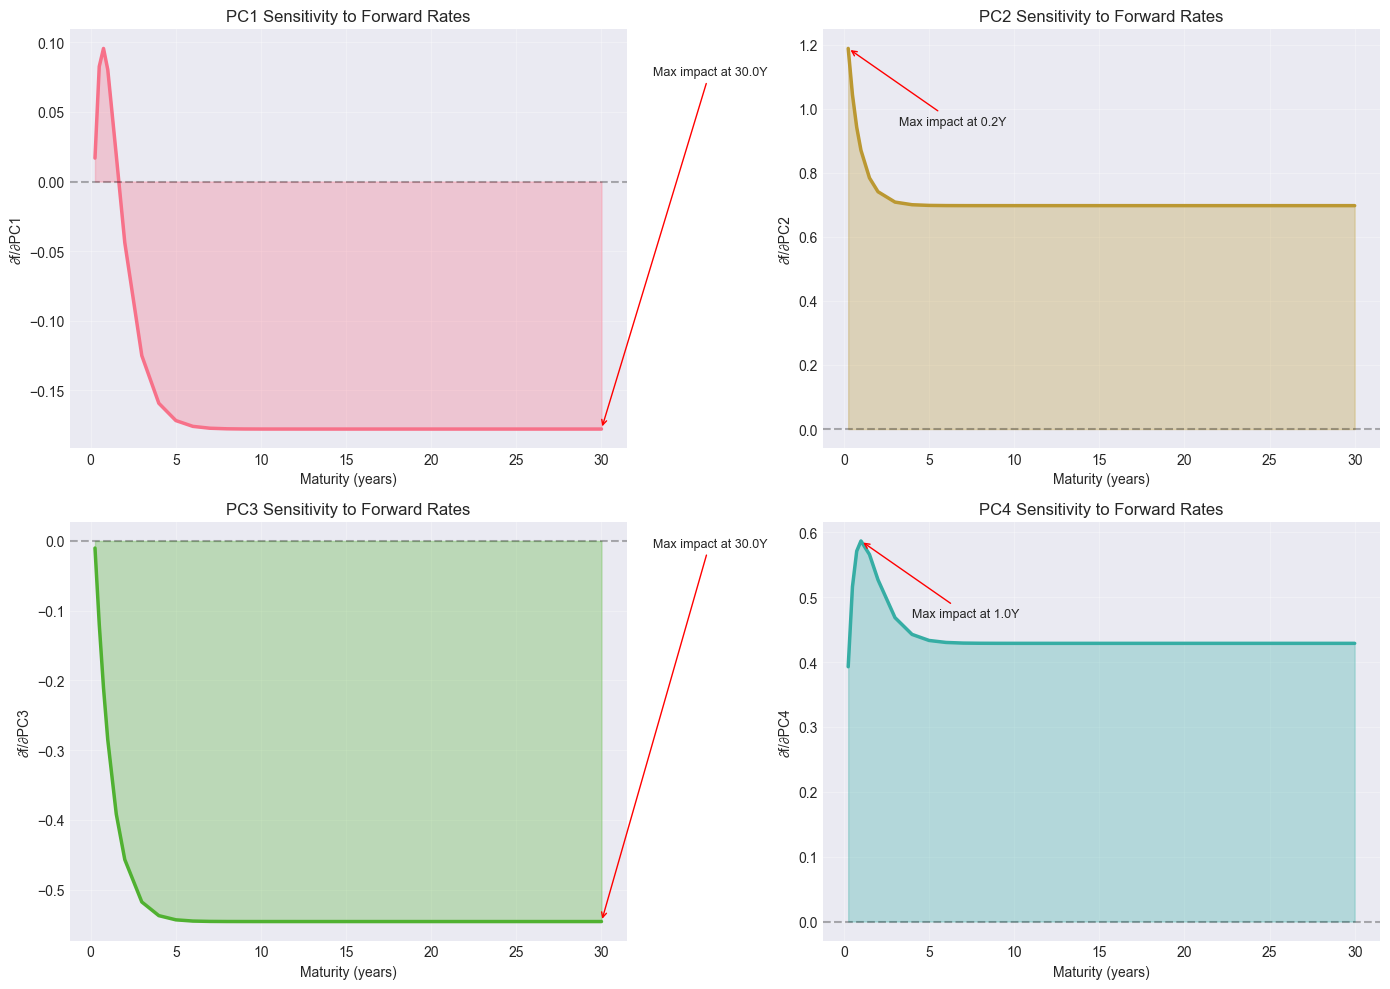


✓ NS SENSITIVITIES COMPUTED AND SAVED
  - NS sensitivities:         data/ns_parameters/ns_sensitivities.csv
  - PC forward sensitivities: data/ns_parameters/pc_forward_sensitivities.csv
  - All data (JSON):          data/ns_parameters/sensitivities.json
  - Visualizations:           data/ns_parameters/ns_sensitivities.png
                              data/ns_parameters/pc_to_forward_sensitivities.png

KEY INSIGHTS:
----------------------------------------------------------------------
PC1:
  Max impact: 0.1779 at 30.0Y maturity
  Interpretation: 1-std-dev move in PC1 → 17.79 bps at 30.0Y
PC2:
  Max impact: 1.1884 at 0.2Y maturity
  Interpretation: 1-std-dev move in PC2 → 118.84 bps at 0.2Y
PC3:
  Max impact: 0.5457 at 30.0Y maturity
  Interpretation: 1-std-dev move in PC3 → 54.57 bps at 30.0Y
PC4:
  Max impact: 0.5867 at 1.0Y maturity
  Interpretation: 1-std-dev move in PC4 → 58.67 bps at 1.0Y


In [8]:
# run compute_ns_sensitivities.py here
%run ../src/calibration/compute_ns_sensitivities.py

## 8. The HJM Simulator

### Architecture: Inputs, Transformations, Outputs

The simulator converts low-dimensional stochastic factor dynamics into full yield curve trajectories. It operates in three layers: what we load (inputs), how we propagate state forward (transformations), and what we return (outputs).

---

### Inputs: Model Components

The simulator relies on several calibrated objects that encode the curve's structure and dynamics:

**1. Nelson–Siegel Parameters (Initial Curve Representation)**

The curve at any time $t$ is represented by four numbers: $\theta_t = (\beta_0, \beta_1, \beta_2, \lambda)^\top$. This is a structural assumption—the curve lives in a low-dimensional NS family rather than having arbitrary shape. The mean parameters $\bar{\theta}$ serve as the central tendency around which the curve fluctuates.

**2. PCA Loadings Matrix**

File: `pca_loadings.csv`

The loadings matrix $L$ provides a linear map from simulated factor vector $\alpha$ (PC scores) to changes in NS parameters:
$$\theta_t = \bar{\theta} + L \cdot \alpha_t$$
where $L$ is $4 \times 4$ and $\alpha_t$ is the vector of principal component scores at time $t$.

> **⚠️ REVISIT LATER:** We should clarify exactly what the PCs represent. Are they from PCA on NS parameters? On yields? On yield changes? The definition determines whether the mapping $L\alpha$ is valid and how to interpret factor movements. This affects the entire simulation's economic interpretation.

**3. OU Parameters for Each PC**

File: `ou_parameters.json`

Each principal component $\alpha_j$ follows an Ornstein–Uhlenbeck process with parameters $(\kappa_j, \theta_j, \sigma_j)$. Under the physical measure $\mathbb{P}$:
$$d\alpha_j = \kappa_j(\theta_j - \alpha_j)\,dt + \sigma_j\,dW_j$$

Under the risk-neutral measure $\mathbb{Q}$, we subtract a market price of risk term $\lambda_j$:
$$d\alpha_j = [\kappa_j(\theta_j - \alpha_j) - \lambda_j]\,dt + \sigma_j\,dW_j$$

> **⚠️ REVISIT LATER:** Currently defaults $\lambda_j = 0$ for all factors. This means $\mathbb{P}$ and $\mathbb{Q}$ dynamics are identical, which is unrealistic. Should calibrate market price of risk from observed bond prices or term premium estimates. Without this, $\mathbb{Q}$-measure simulations are not properly risk-neutral.

**4. Forward Rate Sensitivities**

File: `sensitivities.json`

Contains the composite sensitivities $\frac{\partial f(T)}{\partial PC_j}$ across maturities. These map factor volatilities $\sigma_j$ to forward rate volatilities, which feeds into the HJM drift calculation:
$$\sigma_{\text{forward}}(T) = \sum_j \frac{\partial f(T)}{\partial PC_j} \cdot \sigma_j$$

> **⚠️ REVISIT LATER:** The HJM drift in `_compute_hjm_drift()` uses a discretized approximation rather than the standard closed-form HJM restriction. For a clean finite-factor HJM, we should have volatility shapes $\sigma_i(t,T)$ and compute:
> $$\mu(t,T) = \sum_i \sigma_i(t,T) \int_t^T \sigma_i(t,s)\,ds$$
> The current implementation builds this from `pc_sensitivities` in a way that may not correspond to the true drift for our factorization. This is a common source of "it runs but the math is off."

---

### Transformations: How State Evolves

At each time step $t$ to $t + \Delta t$:

**Step 1: Simulate Factor Increments**

Generate independent Brownian shocks $dW_j \sim \mathcal{N}(0, \Delta t)$ and update each PC score:
$$\alpha_j(t + \Delta t) = \alpha_j(t) + d\alpha_j$$

where $d\alpha_j$ comes from the appropriate OU dynamics ($\mathbb{P}$ or $\mathbb{Q}$ measure).

> **⚠️ REVISIT LATER:** We assume factors are independent (uncorrelated Brownian motions). PCA gives orthogonality in-sample, but OU residuals can reintroduce correlation. Should verify independence or implement correlated Brownian motion if needed.

**Step 2: Map Factors to NS Parameters**

Apply the PCA transformation:
$$\theta(t) = \bar{\theta} + L \cdot \alpha(t)$$

This yields the four NS parameters $(\beta_0, \beta_1, \beta_2, \lambda)$ at time $t$.

**Step 3: Construct Forward Curve**

Evaluate the Nelson–Siegel forward rate formula at each maturity $T$:
$$f(t, T) = \beta_0 + \beta_1 e^{-T/\lambda} + \beta_2 \frac{T}{\lambda} e^{-T/\lambda}$$

**Step 4: Apply HJM Drift Correction (if measure = 'Q')**

If simulating under $\mathbb{Q}$, adjust forward rates using the computed drift:
$$f(t, T) \leftarrow f(t, T) + \mu(t, T) \cdot \Delta t$$

where $\mu(t, T)$ is computed from `_compute_hjm_drift()`.

> **⚠️ CRITICAL CORRECTNESS ISSUE:** This drift adjustment is a proxy, not the true HJM drift for a Nelson–Siegel factor model. The HJM no-arbitrage condition requires:
> $$\mu(t,T) = \sigma(t,T) \int_t^T \sigma(t,s)\,ds$$
> Our implementation approximates this by integrating forward volatilities numerically, but the connection between NS parameters, their dynamics, and the resulting forward volatility structure may not satisfy HJM consistency. This could introduce arbitrage opportunities or mispricing. **This is the main correctness caveat in calling this an "HJM" simulator.**

**Step 5: Convert Forward Curve to Zero Rates**

Integrate the forward curve to obtain zero-coupon yields:
$$y(t, T) = \frac{1}{T} \int_0^T f(t, s)\,ds$$

We use trapezoidal integration over the maturity grid.

---

### Outputs: What the Simulator Returns

The `simulate()` method returns a dictionary containing:

| Key | Shape | Description |
|-----|-------|-------------|
| `pc_paths` | $(n_{\text{paths}}, n_{\text{steps}}, n_{\text{PCs}})$ | Simulated trajectories of PC scores $\alpha_t$ |
| `ns_params` | $(n_{\text{paths}}, n_{\text{steps}}, 4)$ | Implied NS parameter paths $(\beta_0, \beta_1, \beta_2, \lambda)$ |
| `forward_curves` | $(n_{\text{paths}}, n_{\text{steps}}, n_{\text{maturities}})$ | Forward rate surface $f(t, T)$ |
| `zero_curves` | $(n_{\text{paths}}, n_{\text{steps}}, n_{\text{maturities}})$ | Zero rate surface $y(t, T)$ |
| `time_grid` | $(n_{\text{steps}},)$ | Time points $t_0, t_1, \ldots, t_n$ |
| `maturities` | $(n_{\text{maturities}},)$ | Maturity grid for yield curves |

The plotting functions visualize:
- PC score evolution over time
- Final yield curve cross-sections
- 10-year rate time series with confidence bands
- Distribution of terminal 10-year rate

---

### Additional Outputs Worth Considering

> **⚠️ FUTURE ENHANCEMENTS:** For correctness validation and debugging, consider adding:
> 
> 1. **Discount factors**: $P(t,T) = \exp\left(-\int_0^{T-t} f(t,s)\,ds\right)$ with sanity checks (monotonicity, positivity)
> 
> 2. **Martingale tests under $\mathbb{Q}$**: Verify that discounted bond prices $\frac{P(t,T)}{B(t)}$ are martingales empirically from Monte Carlo paths. This tests whether the drift correction is working correctly.
> 
> 3. **Factor attribution**: Decomposition showing which PC drives movements at which maturities. Helps validate that PC1 affects level, PC2 affects slope, etc.
> 
> 4. **NaN/Inf diagnostics**: The code currently can hit non-finite values. Add checks at each step with informative error messages indicating where numerical issues arise.

---

### Using the Simulator

**Physical Measure ($\mathbb{P}$)**: For forecasting and risk analysis
```python
results_P = sim.simulate(
    n_paths=1000,
    T_horizon=1.0,
    measure='P',
    random_seed=42
)
```

**Risk-Neutral Measure ($\mathbb{Q}$)**: For derivatives pricing
```python
results_Q = sim.simulate(
    n_paths=1000,
    T_horizon=1.0,
    measure='Q',
    lambda_risk=None,  # Defaults to zero - SHOULD CALIBRATE
    random_seed=42
)
```

---

### Summary of Current Limitations

This simulator provides a functional pipeline for yield curve simulation using factor models. However, several components require refinement for strict HJM correctness:

1. **Market price of risk is zero by default** → $\mathbb{Q}$ dynamics are identical to $\mathbb{P}$
2. **HJM drift is approximated numerically** → May not satisfy true no-arbitrage restriction
3. **Factor independence assumed** → Should verify or implement correlation structure
4. **No martingale validation** → Cannot confirm $\mathbb{Q}$-measure correctness without testing
5. **PC interpretation unclear** → Need precise definition of what factors represent

These are standard challenges in reduced-form term structure models. The simulator is suitable for scenario analysis and stress testing but should be calibrated more carefully before use in derivatives pricing.